In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pickle
from scipy.special import expit
import time
from itertools import groupby

from sampler import hmc, zz, compute_latent_width
from likelihood import logdensity, grad_logdensity
from momentum import Gaussian, Laplace
from mcmc_diagnostics import estimate_ess
import sys

np.set_printoptions(suppress=True, precision=6)

In [2]:
with open("simulated_data_a0.9_logreg.p", "rb") as f:
    X_int, y, true_idxs, beta_int = pickle.load(f)   

In [3]:

method = "zz"
tau = 1
p_slab = 0.01
tau2_vector = np.array([np.inf] + [tau ** 2] * (X_int.shape[1]-1))
p_slab_vector = np.array([1] + [p_slab] * (X_int.shape[1]-1))
boundary = compute_latent_width(p_slab_vector, tau2_vector) / 2


In [4]:
iters = 30000
burn_in = 0
step_size = 0.02
seed = 0
num_steps = 50
thin = 1

In [5]:
np.random.seed(seed)
beta_init = np.copy(beta_int)

In [6]:
%%time
samples_unadj, meta_unadj = zz(iters * num_steps, beta_init, X_int, y, tau2_vector, p_slab_vector, logdensity, grad_logdensity,
                               step_size, num_steps * thin, adjust=False)

CPU times: user 2h 55min 40s, sys: 2h 40min 12s, total: 5h 35min 52s
Wall time: 42min 22s


with open("unadj3.p", "wb") as f:
    pickle.dump((samples_unadj, meta_unadj), f)

In [8]:
np.random.seed(seed)
beta_init = np.copy(beta_int)

In [9]:
%%time
samples_adj, meta_adj = zz(iters * num_steps, beta_init, X_int, y, tau2_vector, p_slab_vector, logdensity, grad_logdensity,
                           step_size, num_steps * thin, adjust=True)

CPU times: user 5h 41min 46s, sys: 5h 18min 11s, total: 10h 59min 58s
Wall time: 1h 23min 11s


with open("adj3.p", "wb") as f:
    pickle.dump((samples_adj, meta_adj), f)

In [6]:
with open("unadj3.p", "rb") as f:
    samples_unadj, meta_unadj = pickle.load(f)

In [7]:
with open("adj3.p", "rb") as f:
    samples_adj, meta_adj = pickle.load(f)

In [8]:
meta_adj

{'accept_rate': 0.995124}

In [9]:
burn_in = iters // 5
thin = 1

In [15]:
def plot_segments(ax, data, mask):
    slices = []
    values = []
    current_idx = 0
    x = np.arange(len(data))
    for value, group in groupby(mask):
        group_len = len(list(group))
        if value:
            slices.append(slice(current_idx - 1, current_idx + group_len +1))
        else:
            slices.append(slice(current_idx, current_idx + group_len))
        values.append(value)
        current_idx += group_len

    for i, s in enumerate(slices):
        color = "#002D72" if values[i] else "#CF4520"
        ax.plot(x[s], data[s], color=color, lw=1.5)

0.255625
0.2692083333333333


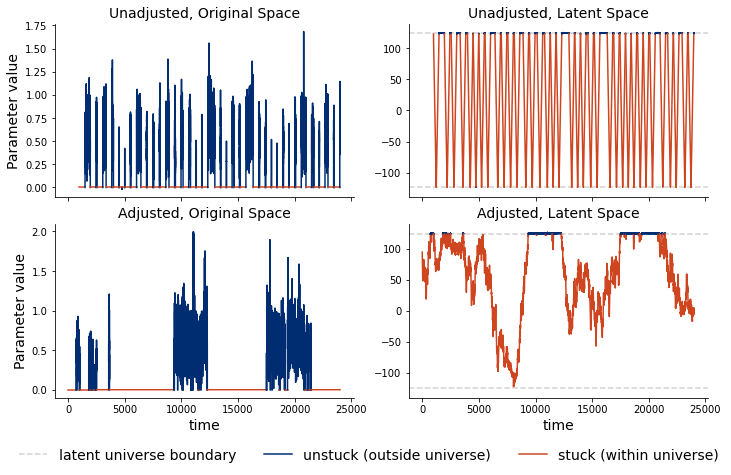

In [16]:
idx = 1464
print(np.mean(samples_unadj["beta"][burn_in::thin, idx] != 0))
print(np.mean(samples_adj["beta"][burn_in::thin, idx] != 0))
fig, ax = plt.subplots(2, 2, figsize=(10,6), sharex=True)

plot_segments(ax[0,0], samples_unadj["beta"][burn_in::thin, idx], samples_unadj["beta"][burn_in::thin, idx] !=0)
ax[0,0].set_title("Unadjusted, Original Space", fontsize=14)
plot_segments(ax[1,0], samples_adj["beta"][burn_in::thin, idx], samples_adj["beta"][burn_in::thin, idx] !=0)
ax[1,0].set_title("Adjusted, Original Space", fontsize=14)
plot_segments(ax[0,1], samples_unadj["latent"][burn_in::thin, idx], abs(samples_unadj["latent"][burn_in::thin, idx]) > boundary[idx])
ax[0,1].set_title("Unadjusted, Latent Space", fontsize=14)
plot_segments(ax[1,1], samples_adj["latent"][burn_in::thin, idx], abs(samples_adj["latent"][burn_in::thin, idx]) > boundary[idx])
ax[1,1].set_title("Adjusted, Latent Space", fontsize=14)

ax[0,0].set_ylabel("Parameter value", fontsize=14)
ax[1,0].set_ylabel("Parameter value", fontsize=14)
ax[1,1].set_xlabel("time", fontsize=14)
ax[1,0].set_xlabel("time", fontsize=14)
ax[0,1].axhline(boundary[idx], linestyle="dashed", color="lightgrey", zorder=-2)
ax[1,1].axhline(boundary[idx], linestyle="dashed", color="lightgrey", zorder=-2)
ax[0,1].axhline(-boundary[idx], linestyle="dashed", color="lightgrey", zorder=-2)
ax[1,1].axhline(-boundary[idx], linestyle="dashed", color="lightgrey", zorder=-2, label="latent universe boundary")
ax[0,1].set_ylim(-140, 140)
ax[1,1].set_ylim(-140, 140)

ax[0,0].spines[["right", "top"]].set_visible(False)
ax[0,1].spines[["right", "top"]].set_visible(False)
ax[1,0].spines[["right", "top"]].set_visible(False)
ax[1,1].spines[["right", "top"]].set_visible(False)

# just for legend
ax[1,1].axhline(-999,  color="#002D72", zorder=-2, label="unstuck (outside universe)")
ax[1,1].axhline(-999,  color="#CF4520", zorder=-2, label="stuck (within universe)")
fig.legend(frameon=False, fontsize=14, bbox_to_anchor=(1.01, 0), ncol=3)
fig.set_constrained_layout(True) 
plt.savefig("/home/andrew/Documents/sticky_samplers/adj_vs_unadj.eps", dpi=300, format='eps', bbox_inches='tight')